## Task 1: Setup

In [6]:
import os
import re
import sys
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


## Task 2: Web Scraping

In [7]:
%%writefile books_spider.py
import scrapy


class BooksToScrapeSpider(scrapy.Spider):
    """Crawls books.toscrape.com and yields one record per book."""

    name = "books_to_scrape"
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]
    max_pages = 6  # enough pages to comfortably clear 100+ books
    pages_visited = 1

    def parse(self, response):
        book_links = response.css("h3 a::attr(href)").getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book_page)

        yield from self._follow_next_page(response)

    def _follow_next_page(self, response):
        next_link = response.css("li.next a::attr(href)").get()
        if next_link and self.pages_visited < self.max_pages:
            self.pages_visited += 1
            yield response.follow(next_link, callback=self.parse)

    def parse_book_page(self, response):
        def field(xpath_expr):
            return response.xpath(xpath_expr).get()

        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": response.xpath('//ul[@class="breadcrumb"]/li[3]/a/text()').get(),
            "price": response.css("p.price_color::text").get(),
            "rating": response.css("p.star-rating::attr(class)").get(),
            "availability": field('//th[text()="Availability"]/following-sibling::td/text()'),
            "description": field('//div[@id="product_description"]/following-sibling::p/text()'),
            "upc": field('//th[text()="UPC"]/following-sibling::td/text()'),
            "reviews": field('//th[text()="Number of reviews"]/following-sibling::td/text()'),
            "url": response.url,
        }


Overwriting books_spider.py


## Task 3: Running the Spider & Storing Output

In [8]:
OUTPUT_CSV = "scraped_data.csv"


def run_spider(script_name: str, output_path: str):
    """Launches the Scrapy spider as a subprocess and reports the outcome."""
    if os.path.exists(output_path):
        os.remove(output_path)

    print(f"Using interpreter: {sys.executable}")
    print("Crawling books.toscrape.com — this usually takes 15-30 seconds...")

    cmd = f'"{sys.executable}" -m scrapy runspider {script_name} -O {output_path}'
    completed = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if os.path.exists(output_path):
        print(f"\nDone — saved to {os.path.abspath(output_path)}")
    else:
        print("\nScrapy did not produce an output file. Log below:")
        print(completed.stderr)

    return completed


result = run_spider("books_spider.py", OUTPUT_CSV)


Using interpreter: c:\Users\kau_shal\miniconda3\envs\ml\python.exe
Crawling books.toscrape.com — this usually takes 15-30 seconds...

Done — saved to d:\drashti\202618023_Drashti_DS605\202618023_Lab_01\scraped_data.csv


## Task 4: Cleaning & Feature Engineering

In [9]:
RATING_WORDS = {
    "star-rating One": 1,
    "star-rating Two": 2,
    "star-rating Three": 3,
    "star-rating Four": 4,
    "star-rating Five": 5,
}


def load_raw(path: str) -> pd.DataFrame:
    frame = pd.read_csv(path)
    print("--- Raw Data Report ---")
    print(f"Rows scraped: {len(frame)}")
    print(f"Missing values per column:\n{frame.isnull().sum()}\n")
    print(f"Duplicate UPCs: {frame.duplicated(subset=['upc']).sum()}\n")
    return frame


def clean_books(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    # Strip stray whitespace and drop duplicate listings
    frame = frame.map(lambda v: v.strip() if isinstance(v, str) else v)
    frame = frame.drop_duplicates(subset=["upc"])

    # Fill missing descriptions
    frame["description"] = frame["description"].fillna("No description available")

    # Numeric conversions
    frame["price"] = frame["price"].str.replace("£", "", regex=False).astype(float)
    frame["stock_count"] = frame["availability"].str.extract(r"(\d+)").astype(float)
    frame["rating"] = frame["rating"].map(RATING_WORDS)

    # --- Engineered features ---
    # 1) Description length measured in characters (previously word count)
    frame["desc_char_count"] = frame["description"].apply(lambda d: len(str(d)))

    # 2) Quartile-based price tier (previously fixed-width price bands)
    frame["price_tier"] = pd.qcut(
        frame["price"], q=4, labels=["Economy", "Standard", "Premium", "Deluxe"]
    )

    # 3) Cost per star — pounds spent per rating point (previously rating/price)
    frame["cost_per_star"] = (frame["price"] / frame["rating"]).round(2)

    # 4) NEW — stock status flag derived from stock_count
    stock_midpoint = frame["stock_count"].median()
    frame["stock_status"] = np.where(
        frame["stock_count"] >= stock_midpoint, "In Stock", "Low Stock"
    )

    return frame


raw_df = load_raw(OUTPUT_CSV)
books_df = clean_books(raw_df)
books_df.to_csv("cleaned_data.csv", index=False)

print("--- Preprocessing Complete ---")
print(f"Cleaned dataset saved as 'cleaned_data.csv' with {len(books_df)} records.")
books_df.head(3)


--- Raw Data Report ---
Rows scraped: 120
Missing values per column:
title           0
category        0
price           0
rating          0
availability    0
description     0
upc             0
reviews         0
url             0
dtype: int64

Duplicate UPCs: 0

--- Preprocessing Complete ---
Cleaned dataset saved as 'cleaned_data.csv' with 120 records.


,title,category,price,rating,availability,description,upc,reviews,url,stock_count,desc_char_count,price_tier,cost_per_star,stock_status
0,Olio,Poetry,23.88,1,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19.0,1574,Standard,23.88,In Stock
1,"Starving Hearts (Triangular Trade Trilogy, #1)",Default,13.99,2,In stock (19 available),"Since her assault, Miss Annette Chetwynd has b...",0312262ecafa5a40,0,https://books.toscrape.com/catalogue/starving-...,19.0,1204,Economy,7.00,In Stock
2,The Dirty Little Secrets of Getting Your Dream...,Business,33.34,4,In stock (19 available),Drawing on his extensive experience evaluating...,2597b5a345f45e1b,0,https://books.toscrape.com/catalogue/the-dirty...,19.0,1857,Standard,8.34,In Stock


## Task 5: Exploratory Visualizations

C:\Users\kau_shal\AppData\Local\Temp\ipykernel_8316\530258460.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=books_df, ax=axes[0, 1], palette="crest")
C:\Users\kau_shal\AppData\Local\Temp\ipykernel_8316\530258460.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kau_shal\AppData\Local\Temp\ipykernel_8316\530258460.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="rating", y="price", data=books_df, ax=axes[1, 1], palette="mako")


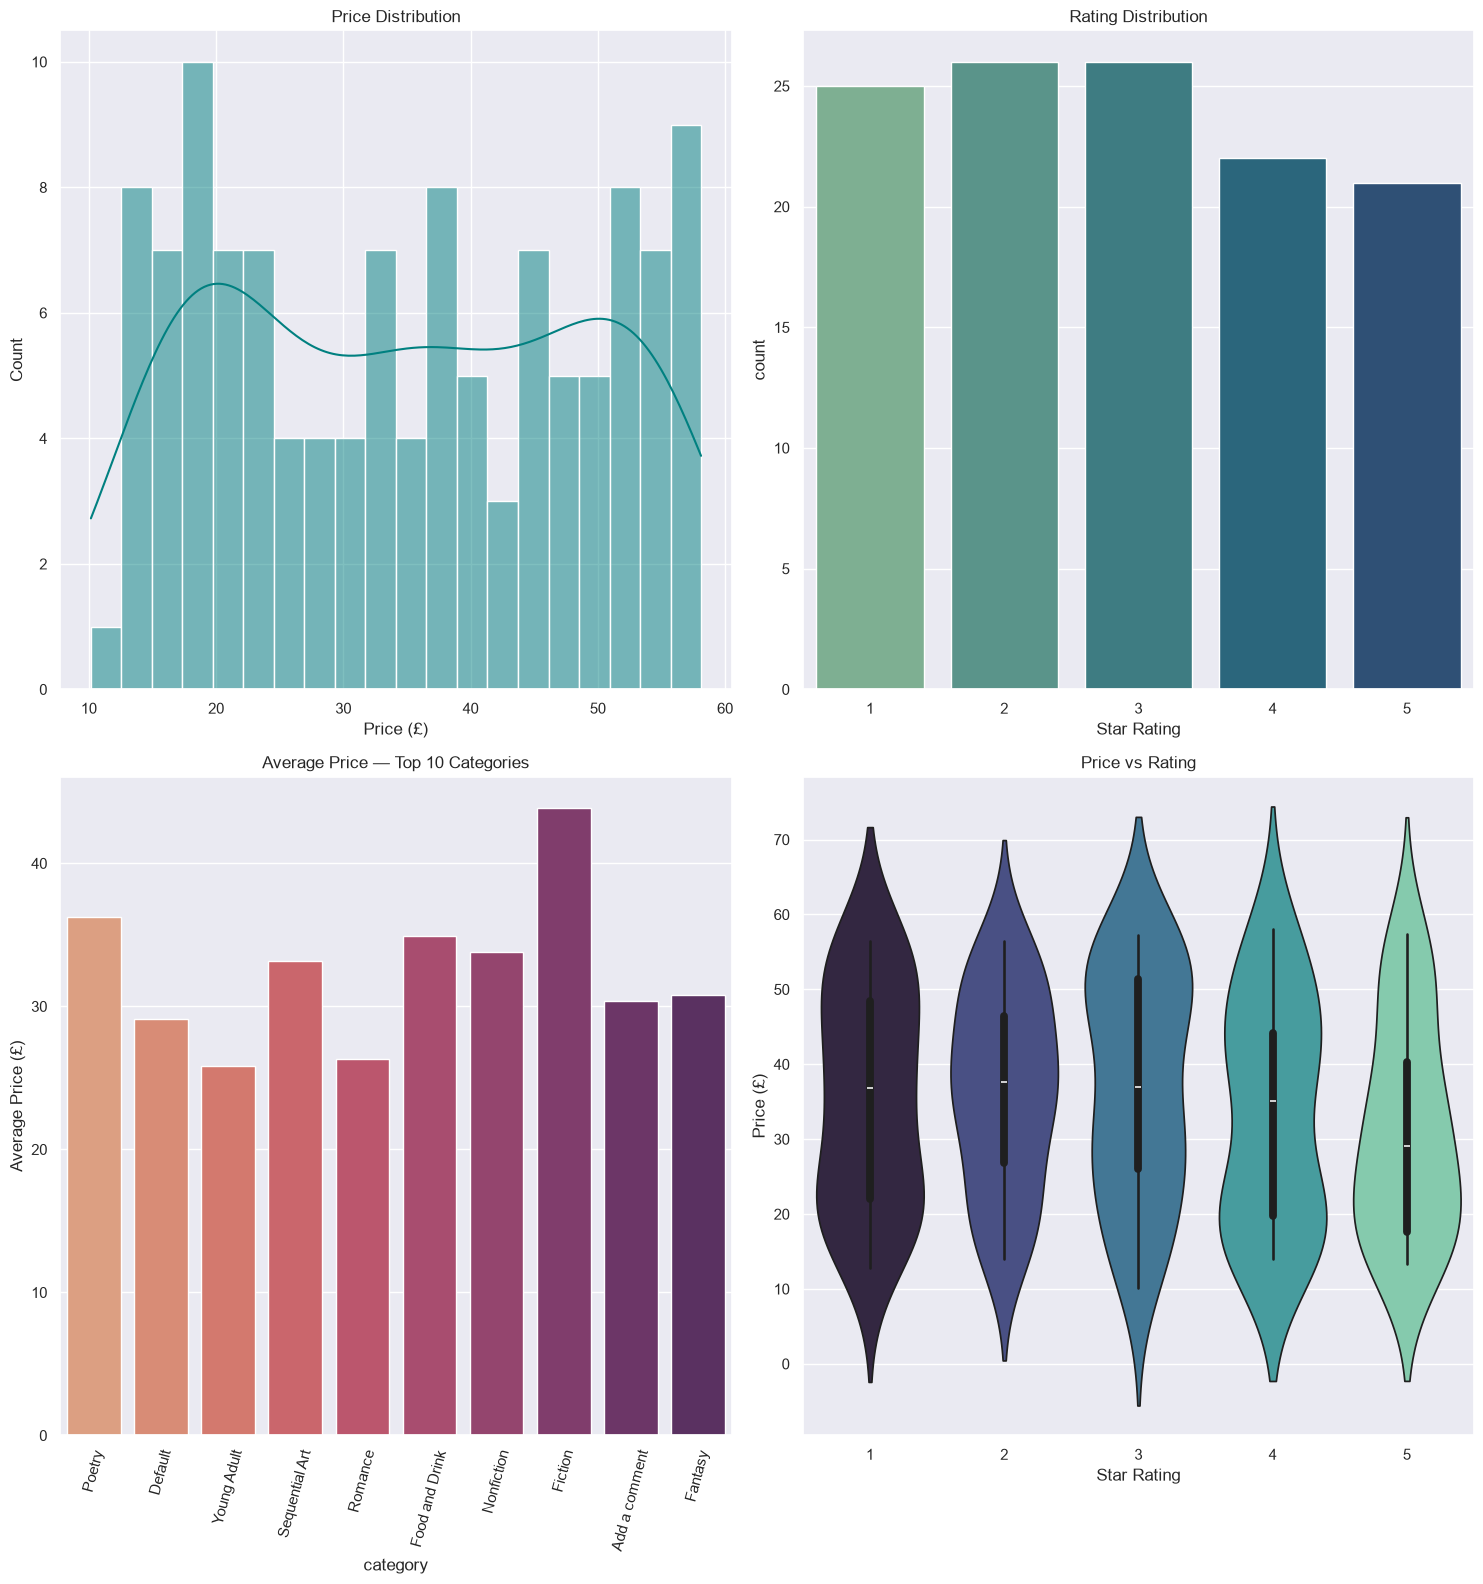

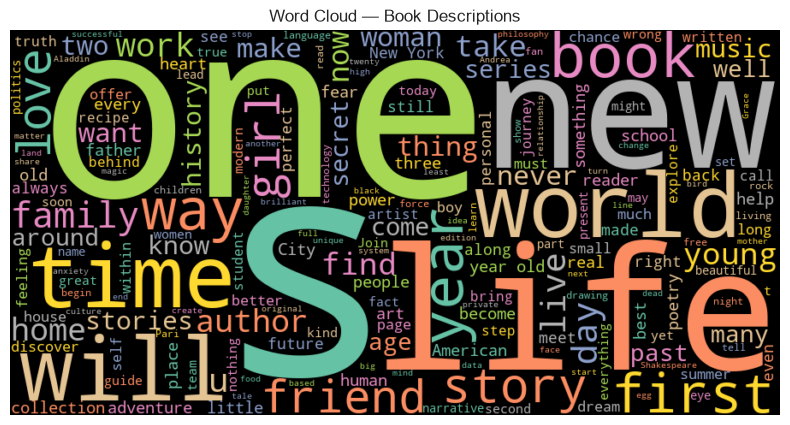

In [11]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 16))

# 1) Price distribution
sns.histplot(books_df["price"], bins=20, kde=True, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price (£)")

# 2) Rating distribution
sns.countplot(x="rating", data=books_df, ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Star Rating")

# 3) Average price for the 10 most common categories
top_categories = books_df["category"].value_counts().head(10).index
category_subset = books_df[books_df["category"].isin(top_categories)]
sns.barplot(
    data=category_subset, y="price", x="category", errorbar=None,
    ax=axes[1, 0], palette="flare",
)
axes[1, 0].set_title("Average Price — Top 10 Categories")
axes[1, 0].set_ylabel("Average Price (£)")
axes[1, 0].tick_params(axis="x", rotation=75)

# 4) Price spread across ratings (violin instead of box, same comparison)
sns.violinplot(x="rating", y="price", data=books_df, ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Price vs Rating")
axes[1, 1].set_xlabel("Star Rating")
axes[1, 1].set_ylabel("Price (£)")



plt.tight_layout()
plt.show()

# Word cloud of descriptions
combined_text = " ".join(books_df["description"].astype(str))
cloud = WordCloud(
    width=900, height=450, background_color="black", colormap="Set2"
).generate(combined_text)

plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Book Descriptions")
plt.show()


## Task 6: Summary

1. Price Distribution

This graph shows that books are available at many different prices, from low to high.
Most books are priced between £15 and £55, giving buyers many options.

2. Rating Distribution

it shows how many books received each star rating.
Most books have 2-star and 3-star ratings, while 5-star books are slightly fewer.

3. Average Price by Top 10 Categories

The cost of books changes from one category to another.
Fiction has the highest average cost, while Young Adult and Romance are generally more affordable.

4. Price vs Rating (Violin Plot)

This shows that readers can find both budget-friendly and costly books, regardless of the star rating.
It means paying more money does not guarantee a better-rated book, and affordable books can also receive excellent ratings.

5. word cloud 

Such as one, life, new, world, time, book, will appear most often in the book descriptions, showing the most common themes and words used by authors